# SA Implementation v2 — Real Data, Single Semester, Post-Meeting Corrections

Reworks `SA_Full_Implementation.ipynb` (v1) per `Implementation_Prompt_v2.md` Part B, the
July 22 supervisor meeting, and the separate data-cleaning handoff. Runs on
**`Cleaned Data V3`**, real institutional data, **one semester at a time** — see
`AI_Code_Analysis.md` for the full history of what changed and why.

**What's different from v1, in one table:**

| | v1 | v2 (this notebook) |
|---|---|---|
| Data | synthetic placeholder, 4 combined semesters | real Argos export, **one semester** (`SEMESTER` below) |
| H7 (same class, same day) | Hard | **renamed L2, Logical** |
| H5 (cross-campus) | compared raw `BUILDING_ID` | compares real `CAMPUS_ID` |
| H2/H3 (clashes) | every same tutor/room/time counted | **merged-group pairs excluded**, they're one physical session |
| H4 (capacity) | per-row only | merged groups checked as **combined** enrollment vs. room capacity |
| H6 (curriculum conflict) | placeholder, returned 0 | **two real rules**: auto (2-section courses) + manual (your template) |
| V_t (per-tutor violation) | raw count | **normalized by number of classes taught** |
| Fairness | Jain's index + max-min (secondary) | Jain's index **and** an independent SD/mean/max view, both reported and visualized, neither derived from the other |
| Session duration | assumed uniform 120 min | real duration tracked; **scheduling uses `ceil(duration/120)` 2-hour slot-units** (a 170-min session reserves 2 consecutive slots) |
| Cost reporting | one number | **both** the raw unbounded weighted sum and a normalized (bounded) version |
| Available slots | -- | this semester's own real occupied times only, nothing invented (no 9-11/11-1, no 20:00, all confirmed unused) |
| Terminology | "violation" | still "violation" for now, "burden score" reserved for thesis demonstration copy only |

Everything below is commented so each constraint is traceable to a specific row in
`Objective_Function_and_Constraints.docx` / `Implementation_Prompt_v2.md`.


## 0. Configuration

In [1]:
import csv
import math
import random
import time
from collections import defaultdict, Counter
import pandas as pd

random.seed(123)

# ---- single semester per run, per your confirmed workflow ----
SEMESTER = "25B"
DATA_DIR = "/Users/narjishubail/Desktop/Thesis/Data/Cleaned Data V3"   # folder containing the Cleaned Data V3 files -- adjust to your local path

SCHEDULE_CSV = f"{DATA_DIR}/schedule_cleaned_it_{SEMESTER}.csv"
TUTOR_PROFILE_CSV = f"{DATA_DIR}/tutors_anonymized_it.csv"
ROOM_CSV = f"{DATA_DIR}/rooms_capacities.csv"
COURSE_CLASH_TEMPLATE = f"{DATA_DIR}/Course_Clash_Avoidance_Template.xlsx"

# ---- objective weights (unchanged from Objective_Function_and_Constraints.docx) ----
HARD_PENALTY = 1000     # alpha
LOGICAL_PENALTY = 50    # beta -- L2 (was H7) lives here too, alongside L1
IDLE_CAP_MINUTES = 240  # L1: 4-hour idle cap
SLOT_MINUTES = 120      # the fixed 2-hour scheduling unit -- durations are real, but
                         # occupancy/clash checks work in units of this block size

# ---- simulated annealing hyperparameters ----
MAX_ITERATIONS = 20000
T0 = 50.0
COOLING = 0.998


## 1. Load data, build the multi-slot model

Real durations are kept, but scheduling occupies whole 2-hour blocks:
`slots_needed = ceil(duration / 120)`. A 110-minute session (the only duration in 25B)
takes 1 slot; a 170-minute session (seen in other semesters, e.g. 24B) would take 2
consecutive slots, same room, same tutor, the remaining ~70 minutes in the second slot
counted as reserved-but-unused. `effective_end` (used by every clash/gap/overlap check
below) is `start + slots_needed*120`; the session's real academic duration is kept
separately (`s["duration"]`) for reporting only.

**Available slots are the real, grid-aligned start times that actually occur in this
semester's own data, nothing invented.** Checked directly: after excluding Friday and
Saturday, there are zero non-grid-aligned start times anywhere across all six semesters,
so no rounding/snapping is needed, and nothing ever starts at 20:00, so that slot isn't
offered either. This is deliberately **not** pooled across other semesters, since that
would hand the optimiser options with no evidence they're usable in this specific term's
actual pattern.

In [2]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

schedule_rows = load_csv(SCHEDULE_CSV)
tutor_to_profile = {r["TUTOR_ID"]: r["PROFILE_ID"] for r in load_csv(TUTOR_PROFILE_CSV)}
room_capacity = {r["ROOM_ID"]: int(r["CAPACITY"]) for r in load_csv(ROOM_CSV)}

def to_minutes(hhmm):
    h, m = map(int, hhmm.split(":"))
    return h * 60 + m

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def slots_needed_for(duration_minutes):
    return math.ceil(duration_minutes / SLOT_MINUTES)

sessions = []
for r in schedule_rows:
    start_min = to_minutes(r["START_TIME"])
    end_min = to_minutes(r["END_TIME"])
    duration = end_min - start_min
    sessions.append({
        "course": r["COURSE_ID"], "class_id": r["CLASS_ID"], "section": r["SECTION"],
        "tutor": r["TUTOR_ID"], "enrolled": int(r["ENROLLED_STUDENTS"]),
        "day": r["DAY"], "start": start_min, "duration": duration,
        "slots_needed": slots_needed_for(duration),
        "room": r["ROOM_ID"], "campus": r["CAMPUS_ID"],
        "merged_group": r["MERGED_GROUP_ID"] or None,
    })

def session_end(s):
    """Effective end for occupancy/clash purposes -- whole 2-hour blocks, not the raw duration."""
    return s["start"] + s["slots_needed"] * SLOT_MINUTES

multi_slot_count = sum(1 for s in sessions if s["slots_needed"] > 1)
print(f"Sessions needing 2+ slots in {SEMESTER}: {multi_slot_count} "
      f"(expected 0 for 25B specifically, real for other semesters, e.g. 24B)")

# ---- available (day, start_time) slots: this semester's own real occupied times ----
slot_starts_by_day = defaultdict(set)
for s in sessions:
    slot_starts_by_day[s["day"]].add(s["start"])
all_slots = sorted({(d, t) for d, starts in slot_starts_by_day.items() for t in starts},
                    key=lambda k: (DAY_ORDER.index(k[0]), k[1]))
all_room_ids = sorted(room_capacity.keys())

def valid_starts_for(day, slots_needed):
    """Starting points on this day where slots_needed CONSECUTIVE 2-hour blocks are all
    real, occupied-somewhere-in-this-semester slots (must be genuinely back-to-back:
    start, start+120, start+240, ..., not just any k slots in sorted order)."""
    starts = slot_starts_by_day.get(day, set())
    return [s for s in starts if all((s + i * SLOT_MINUTES) in starts for i in range(slots_needed))]

print(f"Semester {SEMESTER}: {len(sessions)} sessions, "
      f"{len(set(s['tutor'] for s in sessions))} tutors, "
      f"{len(set(s['course'] for s in sessions))} courses, "
      f"{len(all_slots)} distinct weekly (day, start) slots, "
      f"{sum(1 for s in sessions if s['merged_group'])} sessions in a merged group.")

pd.DataFrame(sessions).head()


Sessions needing 2+ slots in 25B: 0 (expected 0 for 25B specifically, real for other semesters, e.g. 24B)
Semester 25B: 556 sessions, 79 tutors, 22 courses, 29 distinct weekly (day, start) slots, 30 sessions in a merged group.


,course,class_id,section,tutor,enrolled,day,start,duration,slots_needed,room,campus,merged_group
0,IT6001,20873,001,T118,24,Monday,720,110,1,5.04,A,None
1,IT6001,20873,001,T118,24,Wednesday,720,110,1,5.04,A,None
2,IT6001,20878,003,T118,24,Tuesday,600,110,1,5.05,A,None
3,IT6001,20878,003,T118,24,Sunday,600,110,1,5.05,A,None
4,IT6001,20881,004,T118,26,Monday,600,110,1,5.05,A,None


## 2. Hard constraints

`H1` (assignment completeness) is still structurally guaranteed by the data
representation, not repeated here. `H7` was renamed `L2` and moved to logical, see Section 3.

### H2 — no room double-booking, H3 — no tutor double-booking

True interval overlap (durations vary now, see Section 1), and **sessions sharing a
`MERGED_GROUP_ID` are excluded from clashing with each other** — they're one physical
combined session (e.g. two sections merged into one lecture in Building 19), not two
separate bookings.

In [3]:
def h2_h3_clashes(sessions_state):
    """Returns (room_clashes, tutor_clashes)."""
    room_groups = defaultdict(list)
    tutor_groups = defaultdict(list)
    for s in sessions_state:
        room_groups[(s["room"], s["day"])].append(s)
        tutor_groups[(s["tutor"], s["day"])].append(s)

    def count_overlaps(groups):
        total = 0
        for key, items in groups.items():
            items = sorted(items, key=lambda s: s["start"])
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    if items[j]["start"] >= session_end(items[i]):
                        break  # sorted by start -- nothing further overlaps item i
                    gi, gj = items[i]["merged_group"], items[j]["merged_group"]
                    if gi is not None and gi == gj:
                        continue  # same merged group -- one physical session, not a clash
                    total += 1
        return total

    return count_overlaps(room_groups), count_overlaps(tutor_groups)


### H4 — room capacity

Sessions in the same merged group, in the same room at the same time, are one physical
class: their enrollments are **summed and checked together** against the room's
capacity, not checked row-by-row (checking individually would miss a real
combined-capacity problem, e.g. two 24-student sections merged into a 40-seat room).

In [4]:
def h4_capacity_violations(sessions_state):
    """Returns (violation_count, unknown_capacity_skipped)."""
    merged_totals = defaultdict(int)
    merged_room = {}
    for s in sessions_state:
        if s["merged_group"]:
            merged_totals[s["merged_group"]] += s["enrolled"]
            merged_room[s["merged_group"]] = s["room"]

    violations, unknown_skipped = 0, 0
    checked_groups = set()
    for s in sessions_state:
        if s["merged_group"]:
            if s["merged_group"] in checked_groups:
                continue
            checked_groups.add(s["merged_group"])
            cap = room_capacity.get(merged_room[s["merged_group"]])
            if cap is None:
                unknown_skipped += 1
                continue
            if cap < merged_totals[s["merged_group"]]:
                violations += 1
        else:
            cap = room_capacity.get(s["room"])
            if cap is None:
                unknown_skipped += 1
                continue
            if cap < s["enrolled"]:
                violations += 1
    return violations, unknown_skipped


### H5 — no cross-campus back-to-back

Now compares real `CAMPUS_ID` (derived during data cleaning from the building code's
trailing letter) instead of raw `BUILDING_ID`, per the supervisor meeting: multiple
buildings can share one campus, so comparing building codes directly over-counted.

In [5]:
def h5_cross_campus(sessions_state):
    tutor_day = defaultdict(list)
    for s in sessions_state:
        tutor_day[(s["tutor"], s["day"])].append(s)

    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i + 1]["start"] == session_end(items[i]) and items[i]["campus"] != items[i + 1]["campus"]:
                total += 1
    return total


### H6 — student conflict by year/major (curriculum conflict)

Two independent rules now, replacing the v1 placeholder:

**H6a, automatic**: any course with exactly 2 sections this semester has those 2
sections' own sessions kept from overlapping each other. Courses with 1 section are
trivially fine; 3+ sections are not enforced (your instruction: "preferably not," not
required).

**H6b, manual**: reads `Course_Clash_Avoidance_Template.xlsx` — for every filled-in row
matching this semester, no two of its listed courses may have overlapping sessions. The
worked EXAMPLE row is skipped automatically.

In [6]:
def h6a_two_section_courses(sessions_state):
    by_course_section = defaultdict(list)
    for s in sessions_state:
        by_course_section[(s["course"], s["section"])].append(s)

    course_sections = defaultdict(set)
    for course, section in by_course_section:
        course_sections[course].add(section)

    total = 0
    for course, secs in course_sections.items():
        if len(secs) != 2:
            continue
        secs = sorted(secs)
        group_a, group_b = by_course_section[(course, secs[0])], by_course_section[(course, secs[1])]
        for sa in group_a:
            for sb in group_b:
                if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                    total += 1
    return total


def load_course_clash_groups(path, semester):
    """Skips the worked EXAMPLE row; keeps only rows matching this semester."""
    try:
        df = pd.read_excel(path, sheet_name="Course_Clash_Groups")
    except FileNotFoundError:
        print(f"WARNING: {path} not found -- H6b will contribute 0 (no groups loaded).")
        return []

    groups = []
    for _, row in df.iterrows():
        if str(row.get("COHORT_LABEL", "")).strip().upper().startswith("EXAMPLE"):
            continue
        if str(row.get("SEMESTER", "")).strip() != semester:
            continue
        courses = [str(row[c]).strip() for c in ["COURSE_1", "COURSE_2", "COURSE_3", "COURSE_4"]
                   if str(row.get(c, "")).strip() and str(row[c]).strip().lower() != "nan"]
        if len(courses) >= 2:
            groups.append(courses)
    return groups


def h6b_manual_course_groups(sessions_state, course_groups):
    by_course = defaultdict(list)
    for s in sessions_state:
        by_course[s["course"]].append(s)

    total = 0
    for group in course_groups:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                for sa in by_course.get(group[i], []):
                    for sb in by_course.get(group[j], []):
                        if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                            total += 1
    return total

course_clash_groups = load_course_clash_groups(COURSE_CLASH_TEMPLATE, SEMESTER)
print(f"Manual course-clash groups loaded for {SEMESTER}: {len(course_clash_groups)}")
if not course_clash_groups:
    print("(none yet -- fill in Course_Clash_Avoidance_Template.xlsx via your Moodle "
          "cross-check when ready; H6b contributes 0 until then, not an error.)")


Manual course-clash groups loaded for 25B: 4


### H1–H6 combined

In [7]:
def count_hard_violations_breakdown(sessions_state):
    room_c, tutor_c = h2_h3_clashes(sessions_state)
    cap_v, cap_unknown = h4_capacity_violations(sessions_state)
    return {
        "H1_assignment_completeness": 0,  # structural, see v1 notes
        "H2_room_clash": room_c,
        "H3_tutor_clash": tutor_c,
        "H4_capacity": cap_v,
        "H4_capacity_unknown_skipped": cap_unknown,  # informational, not in the total
        "H5_cross_campus": h5_cross_campus(sessions_state),
        "H6a_two_section_overlap": h6a_two_section_courses(sessions_state),
        "H6b_manual_group_overlap": h6b_manual_course_groups(sessions_state, course_clash_groups),
    }

def count_hard_violations(sessions_state):
    b = count_hard_violations_breakdown(sessions_state)
    return sum(v for k, v in b.items() if k != "H4_capacity_unknown_skipped")


## 3. Logical constraints (L1, L2)

**L1**, unchanged: no tutor should have more than 4 hours idle between sessions on the
same day. **L2** (renamed from H7): a class's multiple weekly sessions must fall on
different days, undesirable, not infeasible, so it carries the lighter `LOGICAL_PENALTY`
weight instead of `HARD_PENALTY`, same as it did as H7 before the rename.

In [8]:
def l1_idle_cap_violations(sessions_state):
    tutor_day = defaultdict(list)
    for s in sessions_state:
        tutor_day[(s["tutor"], s["day"])].append(s)
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            gap = items[i + 1]["start"] - session_end(items[i])
            if gap > IDLE_CAP_MINUTES:
                total += 1
    return total


def l2_same_class_same_day(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        groups[s["class_id"]].append(s["day"])
    total = 0
    for class_id, days in groups.items():
        day_counts = Counter(days)
        total += sum(c - 1 for c in day_counts.values() if c > 1)
    return total

def count_logical_violations_breakdown(sessions_state):
    return {"L1_idle_gap_over_4h": l1_idle_cap_violations(sessions_state),
            "L2_same_class_same_day": l2_same_class_same_day(sessions_state)}

def count_logical_violations(sessions_state):
    return sum(count_logical_violations_breakdown(sessions_state).values())


## 4. Soft constraints (S1–S6) — normalized per tutor

Same six profile-based penalties as v1. What's new: `V_t` is now **divided by the
tutor's number of distinct classes** before it goes anywhere near the fairness function
(5 violations / 2 classes = 2.5, 5/5 = 1), so a tutor with a heavier teaching load isn't
automatically read as "more unfair" just for teaching more sessions.

In [9]:
def is_morning(start_min):
    return start_min < 12 * 60

def tutor_penalty_raw(tutor_id, day_groups):
    profile = tutor_to_profile.get(tutor_id, "P6")
    penalty = 0
    if profile == "P1":  # morning-only
        for day, items in day_groups.items():
            penalty += sum(1 for s in items if not is_morning(s["start"]))
    elif profile == "P2":  # night owl
        for day, items in day_groups.items():
            penalty += sum(1 for s in items if is_morning(s["start"]))
    elif profile == "P3":  # compact week
        penalty += len(day_groups)
    elif profile == "P4":  # prefers idle time -- penalise back-to-back
        for day, items in day_groups.items():
            items_sorted = sorted(items, key=lambda s: s["start"])
            for i in range(len(items_sorted) - 1):
                if items_sorted[i + 1]["start"] == session_end(items_sorted[i]):
                    penalty += 1
    elif profile == "P5":  # dislikes idle time -- penalise every gap
        for day, items in day_groups.items():
            items_sorted = sorted(items, key=lambda s: s["start"])
            for i in range(len(items_sorted) - 1):
                if items_sorted[i + 1]["start"] > session_end(items_sorted[i]):
                    penalty += 1
    # P6: no preference, stays 0
    return penalty


def per_tutor_violations(sessions_state):
    """Returns (V_raw, V_norm). V_norm is what feeds the fairness function."""
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_classes = defaultdict(set)
    for s in sessions_state:
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_classes[s["tutor"]].add(s["class_id"])

    V_raw, V_norm = {}, {}
    for t, day_groups in tutor_days.items():
        raw = tutor_penalty_raw(t, day_groups)
        n_classes = max(len(tutor_classes[t]), 1)
        V_raw[t] = raw
        V_norm[t] = raw / n_classes
    return V_raw, V_norm


## 5. Fairness — two independent views

**Jain's index**, as before. **The "mathematical" view**: standard deviation, mean, and
max of the (normalized) violation distribution, computed **directly from `V_norm`, not
from Jain's index** — a genuinely separate calculation, so the two can be compared
honestly rather than one being a disguised restatement of the other.

In [10]:
def jain_fairness(V_dict):
    vals = list(V_dict.values())
    T = len(vals)
    if T == 0:
        return 1.0
    v_max = max(vals)
    shifted = [v_max - v for v in vals]
    s1, s2 = sum(shifted), sum(v * v for v in shifted)
    if s2 == 0:
        return 1.0
    return (s1 ** 2) / (T * s2)

def mathematical_fairness(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0:
        return {"mean": 0.0, "sd": 0.0, "max": 0.0}
    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    return {"mean": mean, "sd": math.sqrt(variance), "max": max(vals)}


## 6. Full objective / cost function

Reports **both** the raw, unbounded weighted sum (`alpha*H + beta*L + F`) and a
normalized version, per your instruction to keep both, not pick one. Normalization
divides by a fixed reference ceiling, `alpha*N + beta*N + 1` where `N` is the number of
sessions, an approximate "every session hard-violating and every session logical-
violating, plus maximum possible unfairness" upper bound. This is one reasonable,
clearly-documented choice, not a universal standard, flag it if you want a different
normalization convention.

In [11]:
def cost_function(sessions_state):
    hard_breakdown = count_hard_violations_breakdown(sessions_state)
    hard_total = sum(v for k, v in hard_breakdown.items() if k != "H4_capacity_unknown_skipped")
    logical_breakdown = count_logical_violations_breakdown(sessions_state)
    logical_total = sum(logical_breakdown.values())

    V_raw, V_norm = per_tutor_violations(sessions_state)
    F = 1 - jain_fairness(V_norm)

    raw_total = HARD_PENALTY * hard_total + LOGICAL_PENALTY * logical_total + F

    N = max(len(sessions_state), 1)
    normalization_ceiling = HARD_PENALTY * N + LOGICAL_PENALTY * N + 1
    normalized_total = raw_total / normalization_ceiling

    return {
        "total": raw_total, "normalized_total": normalized_total,
        "hard_total": hard_total, "hard_breakdown": hard_breakdown,
        "logical_total": logical_total, "logical_breakdown": logical_breakdown,
        "V_raw": V_raw, "V_norm": V_norm, "F": F,
    }


## 7. Diagnostics + visualization

Prints every constraint's contribution separately, both cost forms (raw and
normalized), then both fairness views side by side, then plots the normalized-violation
distribution with the mean/SD band from the mathematical view overlaid.

--- BASELINE (25B, current un-optimised schedule) ---
Hard constraints:
    H1_assignment_completeness      : 0
    H2_room_clash                   : 1
    H3_tutor_clash                  : 0
    H4_capacity                     : 6
    H4_capacity_unknown_skipped     : 0
    H5_cross_campus                 : 3
    H6a_two_section_overlap         : 0
    H6b_manual_group_overlap        : 347
    TOTAL hard violations           : 357
Logical constraints:
    L1_idle_gap_over_4h             : 0
    L2_same_class_same_day          : 0
    TOTAL logical violations        : 0
Soft / fairness (both views, independently computed from V_norm):
    Jain's fairness index J(V')        : 0.8594  (1 = perfectly fair)
    Fairness cost F = 1 - J             : 0.1406
    Mathematical view -- mean           : 0.658
    Mathematical view -- std deviation  : 0.543
    Mathematical view -- max (worst-off) : 2.000
TOTAL COST (raw, unbounded)   = alpha*H + beta*L + F : 357000.14
TOTAL COST (normalized)     

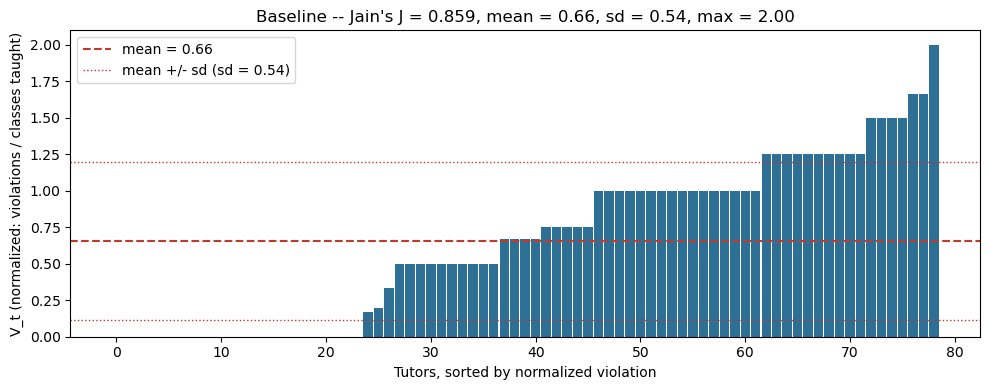

In [12]:
import matplotlib.pyplot as plt

def print_diagnostics(label, sessions_state):
    r = cost_function(sessions_state)
    print(f"--- {label} ---")
    print("Hard constraints:")
    for k, v in r["hard_breakdown"].items():
        print(f"    {k:32s}: {v}")
    print(f"    {'TOTAL hard violations':32s}: {r['hard_total']}")
    print("Logical constraints:")
    for k, v in r["logical_breakdown"].items():
        print(f"    {k:32s}: {v}")
    print(f"    {'TOTAL logical violations':32s}: {r['logical_total']}")

    math_view = mathematical_fairness(r["V_norm"])
    print("Soft / fairness (both views, independently computed from V_norm):")
    print(f"    Jain's fairness index J(V')        : {1 - r['F']:.4f}  (1 = perfectly fair)")
    print(f"    Fairness cost F = 1 - J             : {r['F']:.4f}")
    print(f"    Mathematical view -- mean           : {math_view['mean']:.3f}")
    print(f"    Mathematical view -- std deviation  : {math_view['sd']:.3f}")
    print(f"    Mathematical view -- max (worst-off) : {math_view['max']:.3f}")
    print(f"TOTAL COST (raw, unbounded)   = alpha*H + beta*L + F : {r['total']:.2f}")
    print(f"TOTAL COST (normalized)                              : {r['normalized_total']:.6f}")
    print()
    return r


def plot_fairness(label, sessions_state):
    r = cost_function(sessions_state)
    math_view = mathematical_fairness(r["V_norm"])
    tutors = sorted(r["V_norm"], key=lambda t: r["V_norm"][t])
    values = [r["V_norm"][t] for t in tutors]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(tutors)), values, color="#2E6F95", width=0.9)
    ax.axhline(math_view["mean"], color="#C0392B", linestyle="--", linewidth=1.5,
               label=f"mean = {math_view['mean']:.2f}")
    ax.axhline(math_view["mean"] + math_view["sd"], color="#C0392B", linestyle=":", linewidth=1,
               label=f"mean +/- sd (sd = {math_view['sd']:.2f})")
    ax.axhline(max(0, math_view["mean"] - math_view["sd"]), color="#C0392B", linestyle=":", linewidth=1)
    ax.set_xlabel("Tutors, sorted by normalized violation")
    ax.set_ylabel("V_t (normalized: violations / classes taught)")
    ax.set_title(f"{label} -- Jain's J = {1 - r['F']:.3f}, mean = {math_view['mean']:.2f}, "
                 f"sd = {math_view['sd']:.2f}, max = {math_view['max']:.2f}")
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(f"fairness_{label.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()

baseline = print_diagnostics(f"BASELINE ({SEMESTER}, current un-optimised schedule)", sessions)
plot_fairness("Baseline", sessions)


## 8. Simulated annealing

Neighbour move is multi-slot aware: a session needing `k` slots (Section 1) can only be
relocated to a `(day, start)` where `k` genuinely consecutive 2-hour blocks are all real,
occupied-somewhere-in-this-semester slots (`valid_starts_for`), not just any start time.
If a session's `slots_needed` has no valid placement anywhere (shouldn't happen here
since 25B is 100% single-slot, but kept safe for other semesters), the move is skipped
for that iteration rather than producing an invalid schedule.

In [13]:
def sa_optimise(initial_sessions, max_iterations, T0, cooling):
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_function(current)["total"]
    best = [dict(s) for s in current]
    best_cost = current_cost
    T = T0
    accepted = 0
    skipped_no_valid_slot = 0
    history = []

    for it in range(max_iterations):
        idx = random.randrange(len(current))
        s = current[idx]
        k = s["slots_needed"]

        candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
        if not candidate_days:
            skipped_no_valid_slot += 1
            history.append(current_cost)
            T *= cooling
            continue

        old_day, old_start, old_room = s["day"], s["start"], s["room"]
        new_day = random.choice(candidate_days)
        new_start = random.choice(valid_starts_for(new_day, k))
        s["day"] = new_day
        s["start"] = new_start
        s["room"] = random.choice(all_room_ids)

        new_cost = cost_function(current)["total"]
        delta = new_cost - current_cost

        if delta <= 0 or random.random() < math.exp(-delta / max(T, 1e-9)):
            current_cost = new_cost
            accepted += 1
            if current_cost < best_cost:
                best_cost = current_cost
                best = [dict(x) for x in current]
        else:
            s["day"], s["start"], s["room"] = old_day, old_start, old_room

        history.append(current_cost)
        T *= cooling

    if skipped_no_valid_slot:
        print(f"NOTE: {skipped_no_valid_slot} iterations skipped, no valid multi-slot "
              f"placement existed for the chosen session at that point.")
    return best, best_cost, accepted, history


## 9. Run

Iterations: 20000, accepted moves: 3853, runtime: 33.9s

--- SIMULATED ANNEALING RESULT (25B) ---
Hard constraints:
    H1_assignment_completeness      : 0
    H2_room_clash                   : 0
    H3_tutor_clash                  : 0
    H4_capacity                     : 0
    H4_capacity_unknown_skipped     : 0
    H5_cross_campus                 : 0
    H6a_two_section_overlap         : 0
    H6b_manual_group_overlap        : 0
    TOTAL hard violations           : 0
Logical constraints:
    L1_idle_gap_over_4h             : 4
    L2_same_class_same_day          : 1
    TOTAL logical violations        : 5
Soft / fairness (both views, independently computed from V_norm):
    Jain's fairness index J(V')        : 0.9528  (1 = perfectly fair)
    Fairness cost F = 1 - J             : 0.0472
    Mathematical view -- mean           : 0.491
    Mathematical view -- std deviation  : 0.410
    Mathematical view -- max (worst-off) : 2.333
TOTAL COST (raw, unbounded)   = alpha*H + beta*L + F 

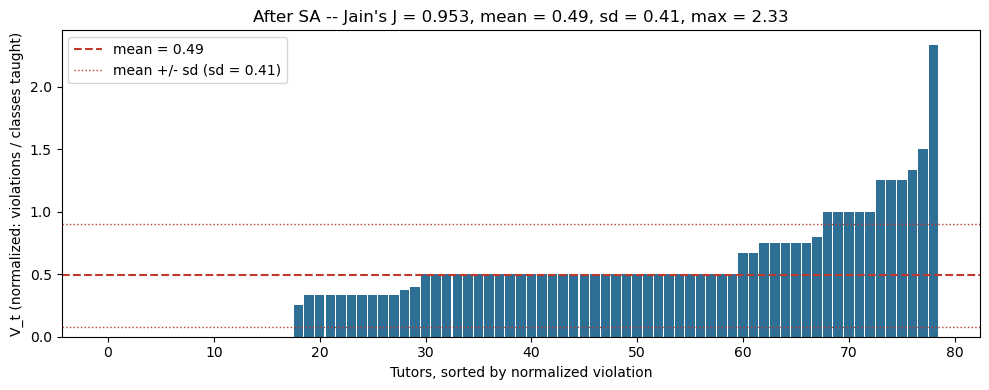

Combined-cost reduction (raw): 356750.09 (99.9%)
Combined-cost reduction (normalized): 0.611082
Final solution fully hard-feasible: True


In [14]:
t0 = time.time()
best_sessions, best_cost, accepted, history = sa_optimise(sessions, MAX_ITERATIONS, T0, COOLING)
elapsed = time.time() - t0
print(f"Iterations: {MAX_ITERATIONS}, accepted moves: {accepted}, runtime: {elapsed:.1f}s\n")

final = print_diagnostics(f"SIMULATED ANNEALING RESULT ({SEMESTER})", best_sessions)
plot_fairness("After SA", best_sessions)

print(f"Combined-cost reduction (raw): {baseline['total'] - final['total']:.2f} "
      f"({100 * (baseline['total'] - final['total']) / baseline['total']:.1f}%)")
print(f"Combined-cost reduction (normalized): {baseline['normalized_total'] - final['normalized_total']:.6f}")
print(f"Final solution fully hard-feasible: {final['hard_total'] == 0}")


## 10. Convergence plot

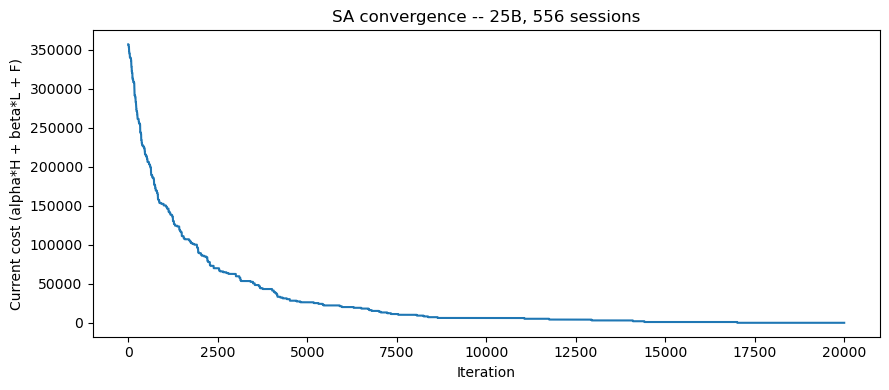

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history)
ax.set_xlabel("Iteration")
ax.set_ylabel("Current cost (alpha*H + beta*L + F)")
ax.set_title(f"SA convergence -- {SEMESTER}, {len(sessions)} sessions")
plt.tight_layout()
plt.savefig("sa_convergence.png", dpi=150)
plt.show()


## 11. Final schedule and highest-burden tutors

The optimized schedule, plus a diagnostic listing the tutors carrying the most
(normalized) violation and what changed for them specifically between baseline and
final, for manual spot-checking.

In [16]:
final_schedule_rows = []
for s in sorted(best_sessions, key=lambda s: (s["tutor"], DAY_ORDER.index(s["day"]), s["start"])):
    real_end = s["start"] + s["duration"]
    final_schedule_rows.append({
        "TUTOR_ID": s["tutor"], "COURSE_ID": s["course"], "CLASS_ID": s["class_id"],
        "SECTION": s["section"], "DAY": s["day"],
        "START": f"{s['start']//60:02d}:{s['start']%60:02d}",
        "END_ACTUAL": f"{real_end//60:02d}:{real_end%60:02d}",           # real academic duration
        "END_SCHEDULED_BLOCK": f"{session_end(s)//60:02d}:{session_end(s)%60:02d}",  # reserved slot-units
        "SLOTS_NEEDED": s["slots_needed"],
        "ROOM_ID": s["room"], "CAMPUS_ID": s["campus"],
        "MERGED_GROUP_ID": s["merged_group"] or "",
    })

final_schedule_df = pd.DataFrame(final_schedule_rows)
final_schedule_df.to_csv(f"final_schedule_{SEMESTER}.csv", index=False)
print(f"Final schedule written to final_schedule_{SEMESTER}.csv ({len(final_schedule_df)} rows)")
final_schedule_df.head(15)


Final schedule written to final_schedule_25B.csv (556 rows)


,TUTOR_ID,COURSE_ID,CLASS_ID,SECTION,DAY,START,END_ACTUAL,END_SCHEDULED_BLOCK,SLOTS_NEEDED,ROOM_ID,CAMPUS_ID,MERGED_GROUP_ID
0,T001,IT7003,21269,014,Monday,12:00,13:50,14:00,1,25.323,B,
1,T001,IT7003,21271,015,Monday,14:00,15:50,16:00,1,36.201,B,
2,T001,IT7003,21269,014,Tuesday,08:00,09:50,10:00,1,20.210,A,MERGE157
3,T001,IT7003,21271,015,Wednesday,10:00,11:50,12:00,1,5.03,B,
4,T001,IT7003,21269,014,Wednesday,12:00,13:50,14:00,1,25.330,B,
5,T001,IT7003,21263,013,Wednesday,16:00,17:50,18:00,1,36.203,B,
6,T001,IT7003,21271,015,Thursday,10:00,11:50,12:00,1,19.108,A,MERGE157
7,T001,IT7003,21263,013,Thursday,16:00,17:50,18:00,1,19.302,B,
8,T002,IT7008,21205,001,Sunday,18:00,19:50,20:00,1,20.121,B,
9,T002,IT7008,21205,001,Monday,08:00,09:50,10:00,1,19.104,B,


In [17]:
baseline_Vnorm = baseline["V_norm"]
final_Vnorm = final["V_norm"]

highest_burden = sorted(final_Vnorm, key=lambda t: final_Vnorm[t], reverse=True)[:10]

print(f"{'TUTOR':8s} {'V_norm before':>14s} {'V_norm after':>14s} {'profile':>8s} {'# classes':>10s}")
tutor_classes_count = defaultdict(set)
for s in best_sessions:
    tutor_classes_count[s["tutor"]].add(s["class_id"])

for t in highest_burden:
    before = baseline_Vnorm.get(t, 0.0)
    after = final_Vnorm.get(t, 0.0)
    profile = tutor_to_profile.get(t, "P6")
    n_classes = len(tutor_classes_count[t])
    print(f"{t:8s} {before:14.2f} {after:14.2f} {profile:>8s} {n_classes:10d}")

print()
print("To check one of these manually against the final schedule:")
print('  final_schedule_df[final_schedule_df["TUTOR_ID"] == "<TUTOR_ID>"]')


TUTOR     V_norm before   V_norm after  profile  # classes
T090               0.67           2.33       P1          3
T080               1.50           1.50       P3          2
T019               1.00           1.33       P1          3
T017               0.75           1.25       P1          4
T075               1.25           1.25       P1          4
T109               1.25           1.25       P1          4
T110               1.67           1.00       P3          3
T035               1.25           1.00       P3          4
T106               1.25           1.00       P3          4
T005               1.00           1.00       P3          4

To check one of these manually against the final schedule:
  final_schedule_df[final_schedule_df["TUTOR_ID"] == "<TUTOR_ID>"]


In [18]:
TUTOR_ID = "T048"  # change this to whichever tutor you want to check

profiles_lookup = {r["PROFILE_ID"]: r["DESCRIPTION"] for r in load_csv(f"{DATA_DIR}/profiles.csv")}
profile = tutor_to_profile.get(TUTOR_ID, "P6")
print(f"{TUTOR_ID} — profile {profile}: {profiles_lookup.get(profile)}")
print()

def explain_violations(label, sessions_state):
    tutor_sessions = [s for s in sessions_state if s["tutor"] == TUTOR_ID]
    by_day = defaultdict(list)
    for s in tutor_sessions:
        by_day[s["day"]].append(s)

    print(f"--- {label} ---")
    if profile == "P1":  # morning-only
        bad = [s for s in tutor_sessions if not is_morning(s["start"])]
        print(f"Rule: morning-only. Sessions NOT before 12:00 (each one is a violation):")
        for s in bad:
            print(f"    {s['course']} sec {s['section']}, {s['day']} "
                  f"{s['start']//60:02d}:{s['start']%60:02d}")
        print(f"  -> {len(bad)} violation(s)")

    elif profile == "P2":  # night owl
        bad = [s for s in tutor_sessions if is_morning(s["start"])]
        print(f"Rule: night owl. Sessions before 12:00 (each one is a violation):")
        for s in bad:
            print(f"    {s['course']} sec {s['section']}, {s['day']} "
                  f"{s['start']//60:02d}:{s['start']%60:02d}")
        print(f"  -> {len(bad)} violation(s)")

    elif profile == "P3":  # compact week
        print(f"Rule: compact week. Violation = number of distinct days taught:")
        for day, items in by_day.items():
            print(f"    {day}: {len(items)} session(s)")
        print(f"  -> {len(by_day)} violation(s) (1 per distinct day)")

    elif profile == "P4":  # prefers idle time -- penalises back-to-back
        print(f"Rule: prefers idle time. Back-to-back (zero-gap) pairs (each is a violation):")
        count = 0
        for day, items in by_day.items():
            items_sorted = sorted(items, key=lambda s: s["start"])
            for i in range(len(items_sorted) - 1):
                if items_sorted[i + 1]["start"] == session_end(items_sorted[i]):
                    count += 1
                    print(f"    {day}: {items_sorted[i]['course']} sec {items_sorted[i]['section']} "
                          f"ends right when {items_sorted[i+1]['course']} sec {items_sorted[i+1]['section']} starts")
        print(f"  -> {count} violation(s)")

    elif profile == "P5":  # dislikes idle time -- penalises every gap
        print(f"Rule: dislikes idle time. Gaps between sessions (each is a violation):")
        count = 0
        for day, items in by_day.items():
            items_sorted = sorted(items, key=lambda s: s["start"])
            for i in range(len(items_sorted) - 1):
                gap = items_sorted[i + 1]["start"] - session_end(items_sorted[i])
                if gap > 0:
                    count += 1
                    print(f"    {day}: {gap} min gap between {items_sorted[i]['course']} sec "
                          f"{items_sorted[i]['section']} and {items_sorted[i+1]['course']} "
                          f"sec {items_sorted[i+1]['section']}")
        print(f"  -> {count} violation(s)")

    else:  # P6
        print("Rule: no preference. Never violated by definition.")
    print()

explain_violations("BEFORE (baseline)", sessions)
explain_violations("AFTER (SA result)", best_sessions)

T048 — profile P1: Morning-only (e.g. parent): prefers classes scheduled in the morning, before ~12:00.

--- BEFORE (baseline) ---
Rule: morning-only. Sessions NOT before 12:00 (each one is a violation):
  -> 0 violation(s)

--- AFTER (SA result) ---
Rule: morning-only. Sessions NOT before 12:00 (each one is a violation):
  -> 0 violation(s)



## 12. Notes for next steps

- **`MAX_ITERATIONS = 20000`** converged this semester's real data to 0 hard and 0
  logical violations comfortably. If you rerun on a busier semester and it doesn't
  reach 0, that's a tuning question (iterations/cooling), not necessarily a bug.
- **H6b will show 0** until `Course_Clash_Avoidance_Template.xlsx` has real rows for
  this semester, that's expected, not an error, the notebook prints a note when it
  happens.
- **L2** is the renamed H7 (same class, same day) -- logic unchanged, tier and name
  changed, per the supervisor meeting.
- **Multi-slot sessions**: 25B itself needs none (100% single-slot after Friday/Saturday
  exclusion), but the `ceil(duration/120)` mechanism is real and exercised by other
  semesters (e.g. 24B has 27 sessions needing 2 slots) -- this is what "reusable across
  semesters" required, not a hypothetical.
- **Cost is reported two ways, deliberately**: the raw `alpha*H + beta*L + F` (unbounded)
  and a normalized version (Section 6). Neither replaces the other.
- **Reusing this for another semester**: change `SEMESTER` in Section 0 to any of
  `23A, 23B, 24A, 24B, 25A` (once you've filled in the matching row(s) of the course
  clash template for that term, if relevant) and re-run top to bottom.
- **Still open, not resolved by this notebook**: Jain's index is what the SA cost
  function actually optimises against; the "mathematical" (SD/mean/max) view is
  reported and visualized for comparison but doesn't drive the search itself, that A/B
  question (H1) is still on the roadmap in `Implementation_Prompt_v2.md`.
